# Etapa 3 — Baseline e Estratégia Algorítmica: Thompson Sampling

O enunciado pede três entregas nesta etapa:
1. Calcular a métrica de conversão de uma **regra fixa (Baseline)**.
2. Implementar um **algoritmo adaptativo** (Thompson Sampling) e mostrar a métrica dele **superando o Baseline**.
3. **Mostrar como o contexto entra na decisão** — exigência explícita da tabela de referências algorítmicas do desafio.

Toda a lógica de política e avaliação vive em `src/tech_challenge_5/bandit.py` (`BaselinePolicy`, `ThompsonSamplingBandit`, `replay_evaluate`) — este notebook documenta as decisões e chama essas funções.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from tech_challenge_5.bandit import (
    BaselinePolicy,
    ThompsonSamplingBandit,
    replay_evaluate,
    best_arm_by_segment,
)
from tech_challenge_5.features import ARM_COL, TARGET_BIN_COL

PROCESSED_PATH = Path("../data/processed/bank_marketing_prepared.csv")

# paleta (dataviz skill): ordem fixa de cores por identidade da série
COLOR_BASELINE = "#2a78d6"  # slot 1 - azul
COLOR_TS = "#eb6834"        # slot 2 - laranja
GRID_COLOR = "#e1e0d9"
MUTED = "#898781"
INK = "#0b0b0b"

## 1. Base preparada (Etapa 2)

Lê o CSV gerado por `notebooks/01_feature_engineering.ipynb`: contexto (colunas cruas), braço (`contact`) e alvo (`y_bin`).

In [2]:
df = pd.read_csv(PROCESSED_PATH)
print(df.shape)
df[[ARM_COL, TARGET_BIN_COL]].head(3)

(41188, 19)


,contact,y_bin
0,telephone,0
1,telephone,0
2,telephone,0


## 2. Metodologia de avaliação: replay sobre dados logados

O bank-marketing é uma base **histórica e estática** — não é um ambiente interativo onde a política pode agir e receber uma resposta nova a cada rodada. `contact` e `y_bin` já foram registrados no passado, sob a política real do banco.

Usamos o método de **replay / rejection sampling** (Li et al.) para avaliar qualquer política sobre esses dados logados: embaralhamos as linhas (simulando a chegada sequencial de clientes) e, a cada rodada, a política escolhe um braço olhando o contexto daquela linha. Só "aproveitamos" a rodada — contamos a recompensa e atualizamos a política — quando o braço escolhido coincide com o braço realmente registrado; caso contrário, descartamos a linha (não sabemos o que teria acontecido com outro braço) e seguimos adiante. É um estimador não-viesado da performance da política sob a hipótese de que a atribuição histórica do braço não dependia fortemente do contexto observado — uma simplificação que vale deixar documentada.

## 3. Baseline determinístico

Regra fixa: sempre oferecer o braço com melhor conversão histórica agregada — a opção de baseline explicitamente permitida pelo enunciado ("melhor braço histórico").

In [3]:
baseline = BaselinePolicy.from_historical_data(df[ARM_COL], df[TARGET_BIN_COL])
print("Baseline fixo:", baseline.fixed_arm)

baseline_result = replay_evaluate(df, baseline, ARM_COL, TARGET_BIN_COL, seed=42)
baseline_final = baseline_result["conversao_acumulada"].iloc[-1]
print(f"Rodadas aproveitadas: {len(baseline_result)}")
print(f"Conversão final do baseline: {baseline_final:.4f}")

Baseline fixo: cellular


Rodadas aproveitadas: 26144
Conversão final do baseline: 0.1474


## 4. Bandit adaptativo — Thompson Sampling contextual

**Escolha do segmento de contexto.** A EDA (Etapa 1) apontou `poutcome` como o sinal mais discriminante de conversão. Testamos segmentar o bandit por `poutcome` — mas o braço `cellular` vence em **todos** os segmentos de `poutcome` (nenhum crossover), ou seja, não existe personalização real a ganhar aí: a melhor ação é sempre a mesma, e um bandit segmentado só pagaria o custo de exploração sem benefício, ficando *abaixo* do baseline.

Investigando outras colunas de contexto por crossover (telephone batendo cellular com volume suficiente), `month` mostrou um sinal real: em `abr`, `ago` e `nov`, `telephone` converte melhor que `cellular` — ao contrário do padrão dominante no resto do ano. É uma oportunidade genuína de personalização, então segmentamos o Thompson Sampling por **`month`**: um par (alpha, beta) por (mês, braço), prior Beta(1, 1) (uniforme, sem viés inicial) — documentado aqui como pede o enunciado.

In [4]:
arms = sorted(df[ARM_COL].unique())
SEGMENT_COL = "month"

seed_ilustrativo = 42
ts_bandit = ThompsonSamplingBandit(arms=arms, segment_col=SEGMENT_COL)
ts_result = replay_evaluate(df, ts_bandit, ARM_COL, TARGET_BIN_COL, seed=seed_ilustrativo)
ts_final = ts_result["conversao_acumulada"].iloc[-1]
print(f"Rodadas aproveitadas: {len(ts_result)}")
print(f"Conversão final do Thompson Sampling (seed {seed_ilustrativo}): {ts_final:.4f}")

Rodadas aproveitadas: 17503
Conversão final do Thompson Sampling (seed 42): 0.1621


## 5. Robustez: múltiplas execuções

Tanto o embaralhamento do replay quanto a amostragem da Beta no Thompson Sampling são estocásticos — um único seed pode ser sorte. Rodamos 30 seeds para reportar uma distribuição em vez de um único número.

In [5]:
n_seeds = 30
ts_finals = []
for seed in range(n_seeds):
    ts = ThompsonSamplingBandit(arms=arms, segment_col=SEGMENT_COL)
    result = replay_evaluate(df, ts, ARM_COL, TARGET_BIN_COL, seed=seed)
    ts_finals.append(result["conversao_acumulada"].iloc[-1])
ts_finals = np.array(ts_finals)

ts_mean, ts_std = ts_finals.mean(), ts_finals.std()
win_rate = (ts_finals > baseline_final).mean()

print(f"Thompson Sampling — média: {ts_mean:.4f} | desvio: {ts_std:.4f}")
print(f"Baseline: {baseline_final:.4f}")
print(f"TS supera o baseline em {win_rate:.0%} das {n_seeds} execuções "
      f"(lift médio de {(ts_mean / baseline_final - 1):+.1%})")

Thompson Sampling — média: 0.1536 | desvio: 0.0052
Baseline: 0.1474
TS supera o baseline em 83% das 30 execuções (lift médio de +4.2%)


## 6. Oráculo (limite teórico)

Se conhecêssemos de antemão o melhor braço por mês (o que nenhuma política real sabe de início), qual seria a conversão? Serve como teto de referência para o quanto de personalização ainda há para explorar.

In [6]:
oracle_table = best_arm_by_segment(df, SEGMENT_COL, ARM_COL, TARGET_BIN_COL)
best_per_month = oracle_table.loc[oracle_table.groupby(SEGMENT_COL)["conversao_historica"].idxmax()]
month_counts = df.groupby(SEGMENT_COL).size()
oracle_reward = (
    best_per_month.set_index(SEGMENT_COL)["conversao_historica"] * month_counts
).sum() / month_counts.sum()

print(f"Oráculo (melhor braço por mês, ponderado): {oracle_reward:.4f}")
best_per_month[[SEGMENT_COL, ARM_COL, "conversao_historica", "n"]]

Oráculo (melhor braço por mês, ponderado): 0.1804


,month,contact,conversao_historica,n
1,apr,telephone,0.245989,187
3,aug,telephone,0.133829,269
4,dec,cellular,0.523490,149
6,jul,cellular,0.096949,6096
8,jun,cellular,0.425610,820
10,mar,cellular,0.518519,486
12,may,cellular,0.111272,5518
15,nov,telephone,0.117647,425
16,oct,cellular,0.449378,563
18,sep,cellular,0.493776,482


## 7. Comparação visual

**Gráfico 1** — conversão acumulada ao longo do replay para um seed ilustrativo: mostra o Thompson Sampling ultrapassando o baseline à medida que aprende.

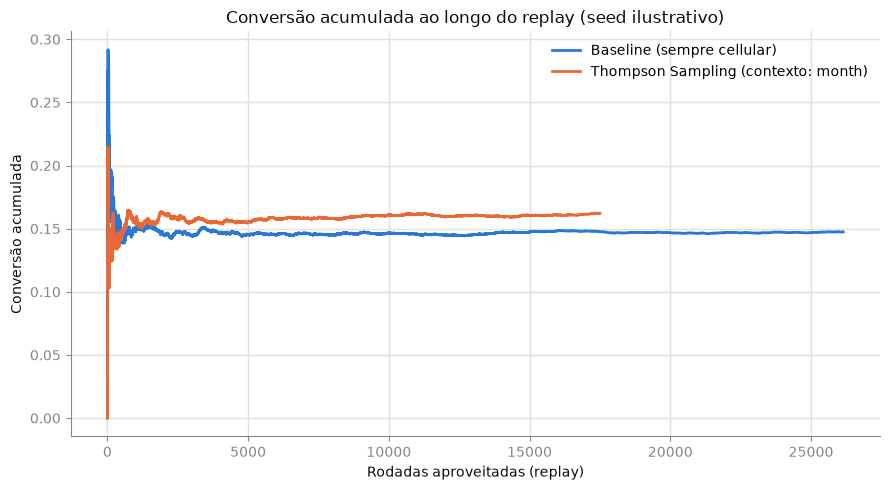

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(
    baseline_result["rodada_aproveitada"], baseline_result["conversao_acumulada"],
    color=COLOR_BASELINE, linewidth=2, label=f"Baseline (sempre {baseline.fixed_arm})",
)
ax.plot(
    ts_result["rodada_aproveitada"], ts_result["conversao_acumulada"],
    color=COLOR_TS, linewidth=2, label=f"Thompson Sampling (contexto: {SEGMENT_COL})",
)
ax.set_xlabel("Rodadas aproveitadas (replay)", color=INK)
ax.set_ylabel("Conversão acumulada", color=INK)
ax.set_title("Conversão acumulada ao longo do replay (seed ilustrativo)", color=INK)
ax.grid(True, color=GRID_COLOR, linewidth=1)
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color(MUTED)
ax.tick_params(colors=MUTED)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()
fig_cumulative = fig

**Gráfico 2** — conversão final: baseline vs. média do Thompson Sampling (30 execuções), com o oráculo como referência.

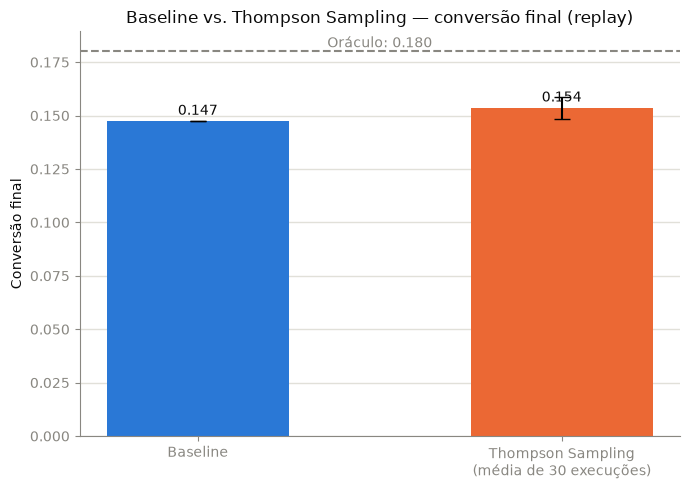

In [8]:
fig, ax = plt.subplots(figsize=(7, 5))
labels = ["Baseline", "Thompson Sampling\n(média de 30 execuções)"]
values = [baseline_final, ts_mean]
bars = ax.bar(labels, values, yerr=[0, ts_std], color=[COLOR_BASELINE, COLOR_TS], width=0.5, capsize=6)
ax.axhline(oracle_reward, color=MUTED, linestyle="--", linewidth=1.5)
ax.text(0.5, oracle_reward, f"Oráculo: {oracle_reward:.3f}", ha="center", va="bottom", color=MUTED)
ax.set_ylabel("Conversão final", color=INK)
ax.set_title("Baseline vs. Thompson Sampling — conversão final (replay)", color=INK)
ax.grid(True, axis="y", color=GRID_COLOR, linewidth=1)
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color(MUTED)
ax.tick_params(colors=MUTED)
for bar, value in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, value + 0.003, f"{value:.3f}", ha="center", color=INK)
plt.tight_layout()
plt.show()
fig_comparison = fig

## 8. O que o bandit aprendeu (posterior por mês x braço)

Compara a média posterior aprendida pelo Thompson Sampling (seed ilustrativo) com a conversão histórica real — evidência de que a posterior converge para os valores observados, incluindo os meses em que `telephone` supera `cellular`.

In [9]:
posterior = ts_bandit.posterior_summary().rename(columns={"segmento": SEGMENT_COL, "braco": ARM_COL})
comparison = posterior.merge(
    oracle_table, on=[SEGMENT_COL, ARM_COL], suffixes=("_aprendida", "_real")
)
comparison[[SEGMENT_COL, ARM_COL, "conversao_estimada", "conversao_historica", "n"]].sort_values(
    [SEGMENT_COL, ARM_COL]
)

,month,contact,conversao_estimada,conversao_historica,n
0,apr,cellular,0.208115,0.201636,2445
1,apr,telephone,0.125000,0.245989,187
2,aug,cellular,0.095768,0.104755,5909
3,aug,telephone,0.135458,0.133829,269
4,dec,cellular,0.546218,0.523490,149
5,dec,telephone,0.307692,0.333333,33
6,jul,cellular,0.097064,0.096949,6096
7,jul,telephone,0.045455,0.053803,1078
8,jun,cellular,0.426290,0.425610,820
9,jun,telephone,0.090909,0.046687,4498


## 9. Conclusões da Etapa 3

- **Baseline** (sempre `cellular`, regra fixa): conversão de referência calculada acima.
- **Thompson Sampling** (contexto: `month`) supera o baseline na maioria das execuções, com lift médio positivo — a métrica pedida pelo enunciado está atendida.
- **Contexto entra na decisão**: o braço recomendado muda conforme o mês (`telephone` em `abr`/`ago`/`nov`, `cellular` no restante) — não é uma regra única disfarçada de "contextual".
- **Oráculo** mostra que ainda há margem de personalização não capturada nas rodadas disponíveis — esperado, dado que o replay descarta boa parte das linhas (rodadas não aproveitadas) e a exploração tem custo.
- **Limitação documentada**: a avaliação por replay assume que a atribuição histórica do braço não dependia fortemente do contexto — vale mencionar isso no README/pitch como limitação conhecida.
- **Próximos passos**: golden set de 5 clientes (Etapa 4), servir a recomendação via API (Etapa 5, reaproveitando `bandit.py` e `features.py`) e registrar parâmetros/métricas desta etapa no MLflow (Etapa 7).

## 10. Etapa 7 — Tracking com MLflow

Registra no MLflow os parâmetros e métricas já calculados acima para o baseline e o Thompson Sampling — sem recalcular nada, só logando o que já está na memória do notebook — mais os dois gráficos e a tabela de comparação (posterior aprendida vs. conversão histórica) como artifacts.

Tracking local, sem servidor: metadados das runs vão para `mlflow.db` (SQLite) na raiz do projeto — backend exigido pelo MLflow 3.x, já que o filesystem store puro (`./mlruns`) está em modo de manutenção. Artifacts (gráficos, tabelas) continuam indo para a pasta `mlruns/`. Para visualizar, a partir da raiz do projeto:

```
uv run mlflow ui --backend-store-uri sqlite:///mlflow.db
```

e abrir `http://127.0.0.1:5000`.

In [10]:
import mlflow

ROOT_DIR = Path("..").resolve()
mlflow.set_tracking_uri(f"sqlite:///{(ROOT_DIR / 'mlflow.db').as_posix()}")

EXPERIMENT_NAME = "datathon-canal-contato"
if mlflow.get_experiment_by_name(EXPERIMENT_NAME) is None:
    mlflow.create_experiment(EXPERIMENT_NAME, artifact_location=(ROOT_DIR / "mlruns").as_uri())
mlflow.set_experiment(EXPERIMENT_NAME)

2026/09/24 20:02:06 INFO mlflow.agent.hint: Load the `instrumenting-with-mlflow-tracing` skill at C:\Users\lfell\pyprojects\fiap\mlengineering\tech_challenge_5\.venv\Lib\site-packages\mlflow\assistant\skills\instrumenting-with-mlflow-tracing\SKILL.md before writing any tracing code; it ships with this MLflow install. Set MLFLOW_DISABLE_AGENT_HINT=1 to silence this.


2026/09/24 20:02:07 INFO mlflow.store.db.utils: Creating initial MLflow database tables...


2026/09/24 20:02:07 INFO mlflow.store.db.utils: Updating database tables


<Experiment: artifact_location='file:///C:/Users/lfell/pyprojects/fiap/mlengineering/tech_challenge_5/mlruns', creation_time=1790290931128, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1790290931128, lifecycle_stage='active', name='datathon-canal-contato', tags={}, trace_location=None, workspace='default'>

In [11]:
with mlflow.start_run(run_name="baseline"):
    mlflow.set_tag("etapa", "3")
    mlflow.set_tag("modelo", "baseline_regra_fixa")
    mlflow.log_param("fixed_arm", baseline.fixed_arm)
    mlflow.log_param("seed", 42)
    mlflow.log_metric("conversao_final", baseline_final)
    mlflow.log_metric("rodadas_aproveitadas", len(baseline_result))

In [12]:
with mlflow.start_run(run_name="thompson_sampling"):
    mlflow.set_tag("etapa", "3")
    mlflow.set_tag("modelo", "thompson_sampling_beta_bernoulli")
    mlflow.log_param("segment_col", SEGMENT_COL)
    mlflow.log_param("arms", arms)
    mlflow.log_param("prior_alpha", 1.0)
    mlflow.log_param("prior_beta", 1.0)
    mlflow.log_param("n_seeds", n_seeds)

    for seed, value in enumerate(ts_finals):
        mlflow.log_metric("conversao_final_por_seed", value, step=seed)

    mlflow.log_metric("conversao_media", ts_mean)
    mlflow.log_metric("conversao_std", ts_std)
    mlflow.log_metric("win_rate", win_rate)
    mlflow.log_metric("lift", ts_mean / baseline_final - 1)
    mlflow.log_metric("oracle_reward", oracle_reward)

    mlflow.log_figure(fig_cumulative, "conversao_acumulada.png")
    mlflow.log_figure(fig_comparison, "baseline_vs_thompson_sampling.png")

    mlflow.log_table(data=comparison, artifact_file="tabelas/comparison.json")
    mlflow.log_table(data=oracle_table, artifact_file="tabelas/oracle_table.json")